# overview of the drosophila dataset intended for samap analysis

Wang et al, 2025 - https://www.cell.com/cell/fulltext/S0092-8674(25)00629-4

In [1]:
import scanpy as sc
dmel_dir = '/staging/leuven/stg_00171/Mark/Dmel_dataset/'
adata_orig = sc.read_h5ad(dmel_dir + 'wcoembed_whole_embeding_downsampled_modified.h5ad')

In [2]:
adata_orig

AnnData object with n_obs × n_vars = 279772 × 16725
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'assay', 'timeslot', 'germ_layer', 'celltype_in_monomics', 'tissue', 'annotation'

In [3]:
adata_orig.var

""
0
1
2
3
4
...
16720
16721
16722
16723


In [4]:
adata = adata_orig.copy()

In [5]:
adata_raw = adata.raw.to_adata()

In [6]:
adata_raw.var_names = adata_raw.var['index']
adata_raw.var_names

Index(['CR11023', 'l(2)gl', 'Cda5', 'CG3625', 'CG3164', 'Ets21C', 'ND-15',
       'galectin', 'spen', 'Sam-S',
       ...
       'lncRNA:CR45394', 'mir-2500', 'snoRNA:Or-CD10', 'mir-13b-2',
       'lncRNA:CR43491', 'tRNA:Lys-TTT-1-1', 'CR43483', 'tRNA:Arg-TCG-2-3',
       'CG34312', 'snoRNA:Or-CD11c'],
      dtype='object', name='index', length=16725)

# 2 reduce to comparable numbers

In [ ]:
## remove cells with zero counts

In [7]:
adata_dm = adata_raw[adata_raw.X.sum(axis=1) > 0].copy()

In [9]:
import numpy as np

# Random reproducible seed
np.random.seed(33)  # Annas number

cell_indices = np.arange(adata_dm.n_obs)
div = len(cell_indices)/30000
subset_indices = np.random.choice(cell_indices, size= int(adata_dm.n_obs // div), replace=False)
print(len(cell_indices))
print(len(subset_indices))

126482
30000


In [10]:
# Subset the AnnData object
adata_subset = adata_dm[subset_indices, :]
adata_subset

View of AnnData object with n_obs × n_vars = 30000 × 16725
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'assay', 'timeslot', 'germ_layer', 'celltype_in_monomics', 'tissue', 'annotation'
    var: 'index'

In [87]:
sc.tl.pca(adata_subset, n_comps=50)

/data/leuven/347/vsc34794/miniconda3/envs/scanpy_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:380: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


In [88]:
sc.pp.neighbors(adata_subset, n_pcs=50)

In [89]:
sc.tl.umap(adata_subset)

In [91]:
dmel_dir = '/staging/leuven/stg_00171/Mark/Dmel_dataset/'
adata_subset.write_h5ad(dmel_dir + 'wcoembed_whole_embeding_downsampled_modified_subset_umap.h5ad')

In [108]:
import scanpy as sc
dmel_dir = '/staging/leuven/stg_00171/Mark/Dmel_dataset/'
adata_subset= sc.read_h5ad(dmel_dir + 'wcoembed_whole_embeding_downsampled_modified_subset_umap.h5ad')

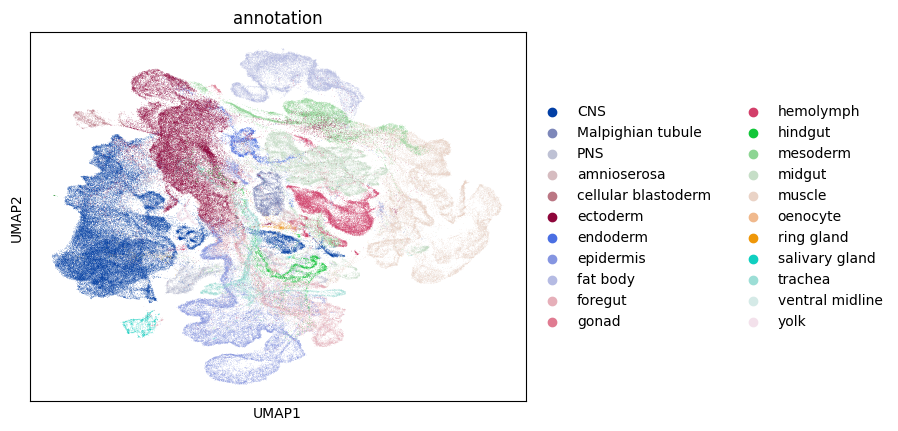

In [20]:
sc.pl.umap(adata, color='annotation')

In [11]:
glia_anno = [
    "astocyte glia",
    "astrocyte glia",
    "chiasm glia",
    "chiasm/cortex glia",
    "chordotonal glia",
    "cortex_glia",
    "glioblasts",
    "midline glia",
    "sensory glia",
    "surface glia"
]

adata_subset.obs["samap_anno"] = adata_subset.obs["annotation"].astype(str)

mask = adata_subset.obs["celltype_in_monomics"].isin(glia_anno)

adata_subset.obs.loc[mask, "samap_anno"] = (
    adata_subset.obs.loc[mask, "celltype_in_monomics"].astype(str)
)

/tmp/ipykernel_1793316/4022838597.py:14: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_subset.obs["samap_anno"] = adata_subset.obs["annotation"].astype(str)


In [12]:
adata_subset.obs['samap_anno'] = adata_subset.obs['samap_anno'].str.replace('astocyte glia', 'astrocyte glia')

# prepare for SAMap

In [17]:
adata_subset.obs[adata_subset.obs['samap_anno'].isin(glia_anno)]

,orig.ident,nCount_RNA,nFeature_RNA,assay,timeslot,germ_layer,celltype_in_monomics,tissue,annotation,samap_anno
CELL7037_N1_1_1,V2R2209070002,4736,1256,RNA,E12-14h,neuroectoderm,astrocyte glia,CNS,CNS,astrocyte glia
CELL8982_N1_2_1,V2R2209070003,1553,817,RNA,E12-14h,neuroectoderm,chordotonal glia,PNS,PNS,chordotonal glia
CELL2657_N1_11_1,V2R2209070012,1903,718,RNA,E16-18h,neuroectoderm,chiasm glia,CNS,CNS,chiasm glia
CELL6537_N1_3_1,V2R2209070004,2759,994,RNA,E12-14h,neuroectoderm,surface glia,CNS,CNS,surface glia
CELL2358_N1_9_1,V2R2209070010,2848,886,RNA,E14-16h,neuroectoderm,chordotonal glia,PNS,PNS,chordotonal glia
...,...,...,...,...,...,...,...,...,...,...
CELL1075_N1_26_2,V2R2209070044,5641,1384,RNA,E10-12h,neuroectoderm,surface glia,CNS,CNS,surface glia
CELL835_N1_6_2,V2R2209070023,1576,807,RNA,E18-20h,neuroectoderm,surface glia,CNS,CNS,surface glia
CELL10550_N1_2_1,V2R2209070003,3502,1042,RNA,E12-14h,mesectoderm,midline glia,ventral midline,ventral midline,midline glia
CELL3076_N1_7_1,V2R2209070008,4722,1589,RNA,E12-14h,neuroectoderm,chiasm glia,CNS,CNS,chiasm glia


In [19]:
dmel_dir = '/staging/leuven/stg_00171/Mark/Dmel_dataset/'
adata_subset.write_h5ad(dmel_dir + 'Dmel_subset_for_samap.h5ad')

# plotting

In [1]:
import scanpy as sc
dmel_dir = '/staging/leuven/stg_00171/Mark/Dmel_dataset/'
adata = sc.read_h5ad(dmel_dir + 'Dmel_subset_for_samap.h5ad')

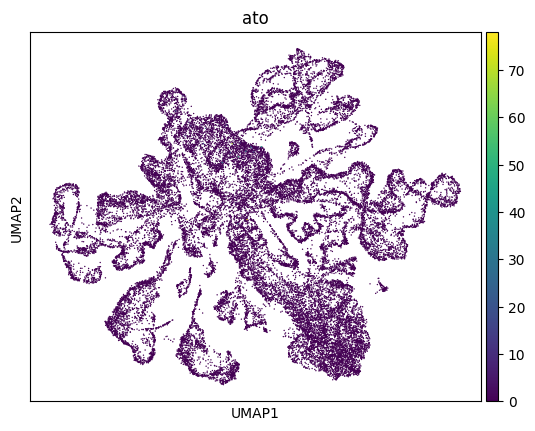

In [8]:
sc.pl.umap(adata, color="ato")

# generate a broader annotation, fitting with the mollusc annotation

In [1]:
import scanpy as sc
dmel_dir = '/staging/leuven/stg_00171/Mark/Dmel_dataset/'
adata = sc.read_h5ad(dmel_dir + 'Dmel_subset_for_samap.h5ad')

In [78]:
mesoderm_adata = adata[adata.obs['germ_layer'] == 'mesoderm']

In [14]:
endoderm_adata = adata[adata.obs['germ_layer'] == 'endoderm']

In [15]:
glia_anno = [
    "astocyte glia",
    "astrocyte glia",
    "chiasm glia",
    "chiasm/cortex glia",
    "chordotonal glia",
    "cortex_glia",
    "glioblasts",
    "midline glia",
    "sensory glia",
    "surface glia"
]

endoderm_adata.obs[endoderm_adata.obs['samap_anno'].isin(glia_anno)]

,orig.ident,nCount_RNA,nFeature_RNA,assay,timeslot,germ_layer,celltype_in_monomics,tissue,annotation,samap_anno


In [2]:
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('trachea', 'NS')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('fat body', 'NS')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('muscle', 'NS')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('midgut', 'NS')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('epidermis', 'NS')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('PNS', 'NS')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('CNS', 'NS')

adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('astocyte glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('astrocyte glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('chiasm glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('chiasm/cortex glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('chordotonal glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('cortex glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('cortex_glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('midline glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('sensory glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('surface glia', 'GLIA')
adata.obs['samap_anno'] = adata.obs['samap_anno'].str.replace('glioblasts', 'GLIA')

In [3]:
mask = adata.obs["germ_layer"].isin(['mesoderm', 'endoderm', 'ectoderm', 'mesectoderm', 'blastoderm', 'extra-embryonic'])

adata.obs["samap_anno"] = adata.obs["samap_anno"].astype(str)

adata.obs.loc[mask, "samap_anno"] = (
    adata.obs.loc[mask, "germ_layer"].astype(str)
)

In [4]:
import scanpy as sc
dmel_dir = '/staging/leuven/stg_00171/Mark/Dmel_dataset/'
adata.write_h5ad(dmel_dir + 'Dmel_subset_for_samap.h5ad')

In [5]:
sc.tl.pca(adata, n_comps=50)

In [6]:
sc.pp.neighbors(adata, n_pcs=50)

/data/leuven/347/vsc34794/miniconda3/envs/scanpy_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
sc.tl.umap(adata)

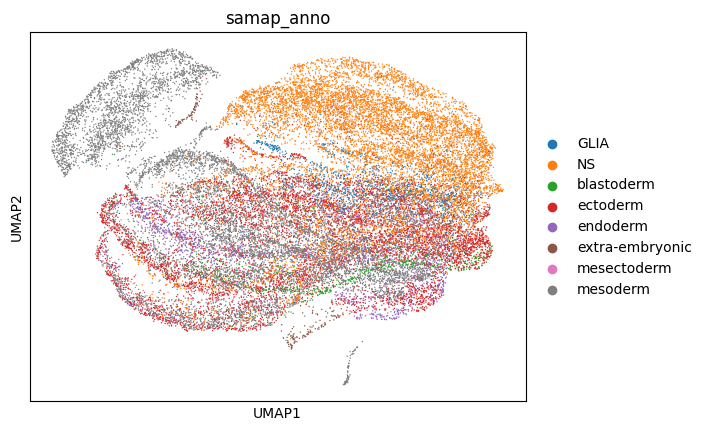

In [8]:
sc.pl.umap(adata, color='samap_anno')

In [3]:
import scanpy as sc
dmel_dir = '/staging/leuven/stg_00171/Mark/Dmel_dataset/'
adata = sc.read_h5ad(dmel_dir + 'Dmel_subset_for_samap.h5ad')

In [4]:
adata.obs['samap_anno'].value_counts()

samap_anno
mesoderm           9726
NS                 9496
ectoderm           6923
endoderm           1872
GLIA               1003
blastoderm          654
extra-embryonic     281
mesectoderm          45
Name: count, dtype: int64